<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ai_labs/MaskRCNNWeek11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import OpenCV for computer vision, NumPy for numerical operations,
# and cv2_imshow to display images in Google Colab
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


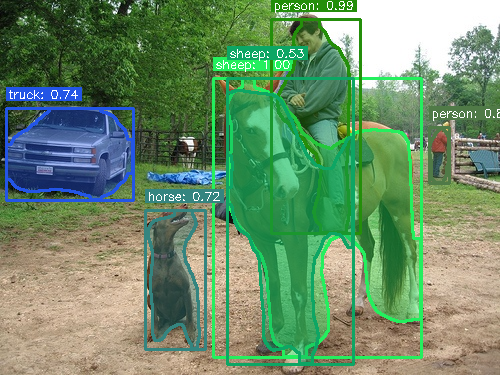

True

In [23]:
# Load the pre-trained Mask R-CNN model with weights and configuration from TensorFlow
net = cv.dnn.readNetFromTensorflow(
    "frozen_inference_graph.pb",
    "mask_rcnn_inception_v2_coco_2018_01_28.pbtxt")

# Load class labels (COCO dataset)
with open("coco_labels.txt", "r") as f:
    classes = f.read().strip().split("\n")

# Load image
image = cv.imread("/content/drive/MyDrive/ai_labs/horse.jpg")
height, width = image.shape[:2]

# Create a blob from the image
blob = cv.dnn.blobFromImage(image, swapRB=True, crop=False)
net.setInput(blob)

# Run forward pass to get detection and masks
boxes, masks = net.forward(["detection_out_final", "detection_masks"])

num_detections = boxes.shape[2]

# Track label Y positions to avoid overlap
used_label_positions = []

for i in range(num_detections):
    score = boxes[0, 0, i, 2]
    if score > 0.5:
        class_id = int(boxes[0, 0, i, 1])
        box = boxes[0, 0, i, 3:7] * np.array([width, height, width, height])
        (x1, y1, x2, y2) = box.astype("int")

        roi = image[y1:y2, x1:x2]
        roi_h, roi_w = y2 - y1, x2 - x1

        # Resize mask to bounding box size
        mask = masks[i, class_id]
        mask = cv.resize(mask, (roi_w, roi_h))
        mask = (mask > 0.3).astype(np.uint8)

        # Generate a unique random color for this instance
        color = np.random.randint(0, 255, (3,), dtype=np.uint8)

        # Blend the mask with the ROI
        roi[mask == 1] = (0.4 * color + 0.6 * roi[mask == 1]).astype(np.uint8)
        image[y1:y2, x1:x2] = roi

        # Draw contour (mask boundary)
        contours, _ = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            cnt += np.array([[x1, y1]])  # shift contour to image coordinates
            cv.drawContours(image, [cnt], -1, color.tolist(), 2)

        # Draw bounding box
        cv.rectangle(image, (x1, y1), (x2, y2), color.tolist(), 2)

        # Prepare label text
        label = f"{classes[class_id]}: {score:.2f}"

        # Use smaller font and thickness
        font_scale = 0.4
        font_thickness = 1
        padding = 2

        # Measure text size
        label_size, _ = cv.getTextSize(label, cv.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
        label_w, label_h = label_size

        # Position label avoiding overlaps
        label_y = y1 - 10
        while any(abs(label_y - used_y) < label_h + 2 for used_y in used_label_positions):
            label_y -= (label_h + 2)

        used_label_positions.append(label_y)

        # Define background rectangle
        top_left = (x1, label_y - label_h - padding)
        bottom_right = (x1 + label_w + padding * 2, label_y + padding)

        # Draw background and label
        cv.rectangle(image, top_left, bottom_right, color.tolist(), cv.FILLED)
        cv.putText(image, label, (x1 + padding, label_y), cv.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)


# Display the result in Colab
cv2_imshow(image)

# Save the result to a file
cv.imwrite("Instance_segmentation_output.jpg", image)